# Exploratory Factor Analysis via Principal Component Extraction

Exploratory Factor Analysis (EFA) is a statistical procedure utilized to evaluate relationships among observed variables. The initial phase of EFA is factor extraction. Principal Component Analysis (PCA) serves as a method for this extraction process. Factor weights are computed to extract the maximum possible variance. Successive factoring continues until there is no further meaningful variance left. The resulting factor model is then rotated to achieve a structure suitable for final analysis.

This notebook demonstrates these steps using synthetic data representing aptitude test scores.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# data generation
np.random.seed(42)
n_samples = 500

quantitative_factor = np.random.normal(0, 1, n_samples)
verbal_factor = np.random.normal(0, 1, n_samples)

algebra_test = 0.85 * quantitative_factor + np.random.normal(0, 0.5, n_samples)
geometry_test = 0.80 * quantitative_factor + np.random.normal(0, 0.5, n_samples)
physics_test = 0.75 * quantitative_factor + np.random.normal(0, 0.5, n_samples)

reading_test = 0.85 * verbal_factor + np.random.normal(0, 0.5, n_samples)
writing_test = 0.80 * verbal_factor + np.random.normal(0, 0.5, n_samples)
literature_test = 0.75 * verbal_factor + np.random.normal(0, 0.5, n_samples)

data = pd.DataFrame({
    'Algebra': algebra_test,
    'Geometry': geometry_test,
    'Physics': physics_test,
    'Reading': reading_test,
    'Writing': writing_test,
    'Literature': literature_test
})

display(data.head())

,Algebra,Geometry,Physics,Reading,Writing,Literature
0,1.121885,0.786552,0.034946,1.072557,-0.212962,1.284954
1,0.344792,-0.386204,-0.175958,2.107096,1.097341,1.118406
2,0.580350,0.109051,0.089556,-1.354437,-1.325657,-1.026314
3,0.971107,1.216737,0.988292,0.172405,1.394219,0.447826
4,0.150081,-0.272415,-1.122422,-1.095621,-0.242237,-0.738874


## Phase 1: Standardization and Covariance
Prior to PCA, the data must be standardized to ensure that variables with larger numerical ranges do not disproportionately dominate the variance extraction process.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

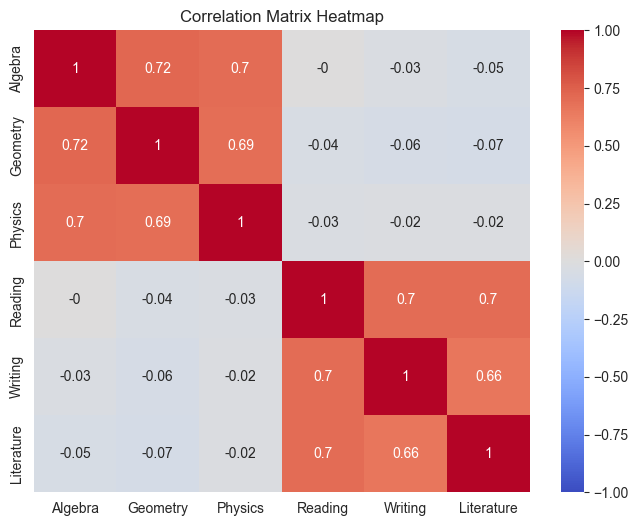

In [3]:
import seaborn as sns

correlation_matrix = pd.DataFrame(data_scaled).corr().round(2)
correlation_matrix.index = data.columns
correlation_matrix.columns = data.columns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Phase 2: Factor Extraction using PCA
PCA computes factor weights to extract the maximum possible variance. Successive components account for decreasing amounts of residual variance. We examine the eigenvalues to determine when there is no further meaningful variance left to extract.

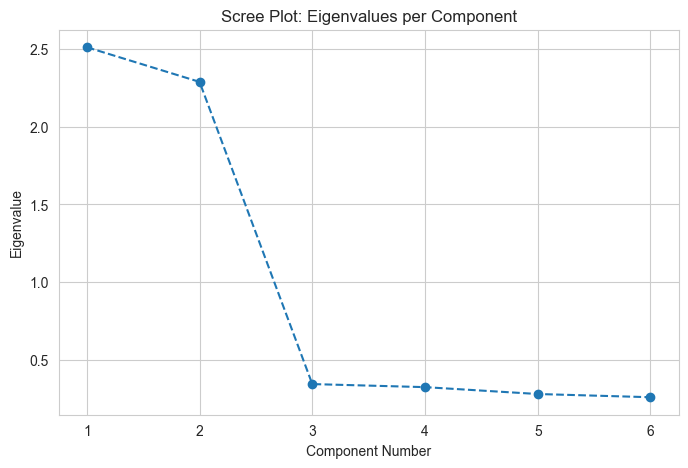

In [4]:
pca = PCA()
pca.fit(data_scaled)

eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--')
plt.title('Scree Plot: Eigenvalues per Component')
plt.xlabel('Component Number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

## Phase 3: Factor Rotation
While PCA extracts the variance effectively, the initial unrotated axes are mathematically orthogonal but often difficult to interpret. The factor model must be rotated for analysis. Orthogonal rotation (e.g., Varimax) redistributes the explained variance for individual variables, maximizing the variance of squared loadings to achieve a simple structure.

In [5]:
import pandas as pd

eigenvectors = pca.components_
eigenvalues = pca.explained_variance_

unrotated_loadings = eigenvectors.T * np.sqrt(eigenvalues)

unrotated_df = pd.DataFrame(
    unrotated_loadings, 
    index=data.columns, 
    columns=[f'Factor {i+1}' for i in range(6)]
)
display(unrotated_df.round(3))

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6
Algebra,0.681,0.590,-0.135,-0.168,-0.287,-0.246
Geometry,0.703,0.561,-0.096,-0.154,0.396,0.054
Physics,0.669,0.585,0.244,0.326,-0.106,0.187
Reading,-0.605,0.671,-0.115,-0.216,-0.140,0.326
Writing,-0.600,0.651,-0.290,0.328,0.080,-0.141
Literature,-0.614,0.638,0.402,-0.117,0.080,-0.191


In [6]:
from factor_analyzer.rotator import Rotator

rotator = Rotator(method='varimax')

rotated_loadings_array = rotator.fit_transform(unrotated_loadings)

rotated_df = pd.DataFrame(
    rotated_loadings_array, 
    index=data.columns, 
    columns=[f'Factor {i+1}' for i in range(6)]
)

display(rotated_df.round(3))

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6
Algebra,0.874,-0.010,-0.024,0.343,0.346,0.010
Geometry,0.346,-0.022,-0.032,0.339,0.875,-0.013
Physics,0.322,-0.002,0.002,0.892,0.319,-0.019
Reading,0.010,0.355,0.354,-0.020,-0.010,0.866
Writing,-0.010,0.895,0.312,-0.002,-0.020,0.320
Literature,-0.024,0.312,0.895,0.001,-0.030,0.320


## Simple visualization of PCA 

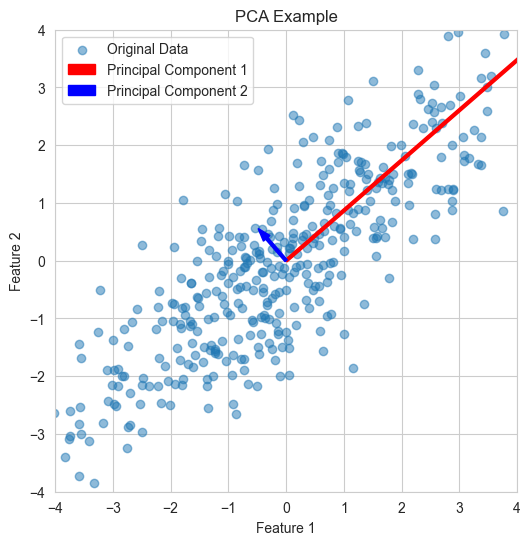

Variance along Principal Component 1: 6.37028438951233
Variance along Principal Component 2: 0.5136386683722021
Orthogonality of Principal Components: 8.0805879695081e-18


In [7]:
np.random.seed(42)
X = np.dot(np.random.rand(2, 2) * 2, np.random.randn(2, 400)).T

# PCA mit zwei Komponenten fitten
pca = PCA(n_components=2)
pca.fit(X)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data')

# X und Y Achsen gleich machen damit die Orthogonalität der Principal Components sichtbar wird
plt.autoscale(False)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-4, 4)
plt.ylim(-4, 4)

# Plot der Principal Components
# Vektorlänge wird durch die Varianz bestimmt
plt.arrow(
    0,
    0,
    pca.components_[0, 0] * pca.explained_variance_[0],
    pca.components_[0, 1] * pca.explained_variance_[0],
    color='red',
    width=0.05,
    label='Principal Component 1'
)
plt.arrow(
    0,
    0,
    pca.components_[1, 0] * pca.explained_variance_[1],
    pca.components_[1, 1] * pca.explained_variance_[1],
    color='blue',
    width=0.05,
    label='Principal Component 2'
)
plt.legend()
plt.title('PCA Example')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print the variance along the principal components
print(f'Variance along Principal Component 1: {pca.explained_variance_[0]}')
print(f'Variance along Principal Component 2: {pca.explained_variance_[1]}')
print(f'Orthogonality of Principal Components: {np.dot(pca.components_[0], pca.components_[1])}')
